# Demo: Sistema de Contagem e Valoração de Moedas em Imagens

**Objetivo:** Este notebook demonstra como desenvolver um sistema automatizado para detectar, contar e calcular o valor total de moedas em imagens.

---

## 1. Importações

In [1]:
# Bibliotecas para processamento de imagens e visualização
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from io import BytesIO
import requests
from PIL import Image

# Configuração para exibir gráficos inline
%matplotlib inline

## 2. Função para Download de Imagens

Como as imagens estão hospedadas na web, precisamos de uma função para fazer o download e salvar localmente:

In [2]:
def download_image(url):
    try:
        response = requests.get(url)
        response.raise_for_status()
        
        filename = url.split('/')[-1]
        
        # Salvar imagem localmente
        with open(filename, 'wb') as f:
            f.write(response.content)
        
        print(f"Imagem {filename} baixada com sucesso")
        return filename
    
    except Exception as e:
        print(f"Erro ao baixar imagem: {e}")
        return None

## 3. Carregamento das Imagens de Teste

Vamos baixar as imagens de teste do repositório da UNICAMP e visualizá-las:

In [3]:
# URLs das imagens de teste
url_base = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/{value}.jpg"
values = [75, 80, 95]  # Identificadores das imagens

# Download das imagens
filenames = []
for value in values:
    url = url_base.format(value=value)
    filename = download_image(url)
    if filename:
        filenames.append(filename)

print(f"\n✓ Total de {len(filenames)} imagens carregadas")

Imagem 75.jpg baixada com sucesso
Imagem 80.jpg baixada com sucesso
Imagem 95.jpg baixada com sucesso

✓ Total de 3 imagens carregadas


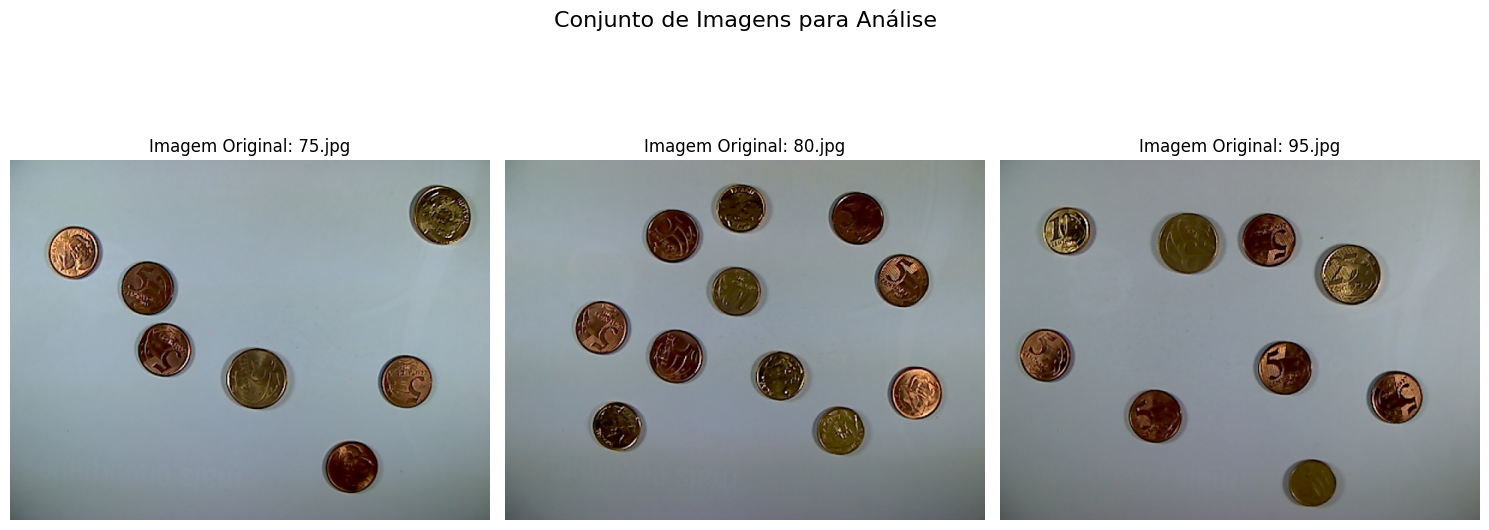

In [4]:
# Visualização das imagens originais
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

for i, filename in enumerate(filenames):
    plt.subplot(1, 3, i+1)
    plt.axis('off')
    plt.title(f'Imagem Original: {filename}', fontsize=12)
    
    img = mpimg.imread(filename)
    plt.imshow(img)

plt.suptitle('Conjunto de Imagens para Análise', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Observações sobre as imagens:**
- Cada imagem contém diferentes quantidades e valores de moedas
- As moedas aparecem sobre fundos variados
- Há variações de iluminação e contraste

## 4. Função de Segmentação e Pós-processamento

Esta função é o coração do processamento de imagens. Ela segmenta as moedas do fundo utilizando técnicas avançadas:

In [5]:
def seg_and_postprocessing(img, k_cl, k_op):
    """Segmentação de moedas usando threshold automático e operações morfológicas.
    
    Args:
        img (np.array): Imagem em escala de cinza
        k_cl (int): Tamanho do kernel para closing
        k_op (int): Tamanho do kernel para opening
        
    Returns:
        np.array: Imagem binária segmentada
    """
    print(f"Aplicando segmentação com kernels: closing={k_cl}x{k_cl}, opening={k_op}x{k_op}")
    
    # 1. Threshold automático usando método de Otsu
    # Inversão (255-img) para que moedas fiquem brancas
    _, binr = cv2.threshold(255 - img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    kernel_cl = np.ones((k_cl, k_cl), np.uint8)  # Kernel para closing
    kernel_op = np.ones((k_op, k_op), np.uint8)  # Kernel para opening
    
    # 3. Operação de Closing (dilatação seguida de erosão)
    # Objetivo: Fechar pequenos buracos dentro das moedas
    close = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel_cl, iterations=1)
    
    # 4. Operação de Opening (erosão seguida de dilatação)  
    # Objetivo: Remover ruídos pequenos e separar objetos conectados
    open_img = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op, iterations=1)
    
    # Visualização das etapas de processamento
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(binr, cmap='gray')
    plt.title('1. Threshold de Otsu')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(close, cmap='gray')
    plt.title('2. Após Closing')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(open_img, cmap='gray')
    plt.title('3. Após Opening (Final)')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return open_img

**Utilizei:**

1. **[Threshold de Otsu](https://docs.opencv.org/master/d7/d4d/tutorial_py_thresholding.html):** Método automático que encontra o valor ótimo de threshold baseado na análise do histograma da imagem

2. **[Operações Morfológicas](https://docs.opencv.org/master/d9/d61/tutorial_py_morphological_ops.html):**
   - **Closing:** Remove buracos pequenos dentro dos objetos
   - **Opening:** Remove ruído e separa objetos conectados

3. **Elementos Estruturantes:** Kernels quadrados que definem a forma e tamanho das operações morfológicas

## 5. Função para Cálculo da Área dos Objetos

Esta função calcula o número de pixels de cada objeto segmentado, informação crucial para classificação:

In [6]:
def calc_npixels_label(img, n_labels):
    """Calcula o número de pixels para cada componente conectado.
    
    Args:
        img (np.array): Imagem com labels dos componentes conectados
        n_labels (int): Número total de labels (incluindo background)
        
    Returns:
        list: Lista com número de pixels de cada objeto (excluindo background)
    """
    list_npixels = []
    
    # Itera através de todos os labels (exceto background = 0)
    for label_id in range(1, n_labels):
        # Conta pixels com valor igual ao label atual
        # A divisão por label_id normaliza o valor para 1, depois soma
        npixels = (img[img == label_id] // label_id).sum()
        list_npixels.append(npixels)
        print(f"Objeto {label_id}: {npixels} pixels")
    
    return list_npixels

**Área é importante porque:**
- Moedas de valores diferentes têm tamanhos diferentes
- A área (número de pixels) é uma característica discriminativa
- Permite classificação simples baseada em thresholds de área

## 6. Algoritmo Principal de Detecção e Valoração


PROCESSANDO IMAGEM 1: 75.jpg
Imagem carregada: (480, 640, 3)
Conversão para escala de cinza concluída

--- ETAPA DE SEGMENTAÇÃO ---
Aplicando segmentação com kernels: closing=15x15, opening=31x31


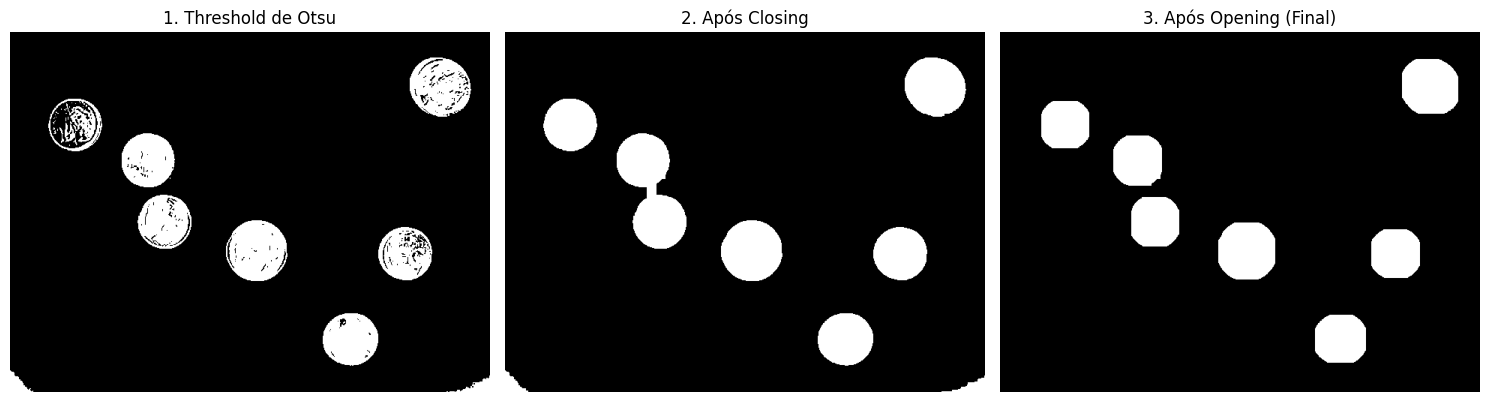


--- ANÁLISE DE COMPONENTES CONECTADOS ---
 Encontrados 7 objetos (excluindo background)

--- CÁLCULO DE ÁREAS ---
Objeto 1: 4805 pixels
Objeto 2: 3638 pixels
Objeto 3: 3867 pixels
Objeto 4: 3786 pixels
Objeto 5: 5016 pixels
Objeto 6: 3767 pixels
Objeto 7: 3861 pixels

--- CLASSIFICAÇÃO E VALORAÇÃO ---
Objeto 1: 4805 pixels → 25 centavos
Objeto 2: 3638 pixels → 5 centavos
Objeto 3: 3867 pixels → 5 centavos
Objeto 4: 3786 pixels → 5 centavos
Objeto 5: 5016 pixels → 25 centavos
Objeto 6: 3767 pixels → 5 centavos
Objeto 7: 3861 pixels → 5 centavos


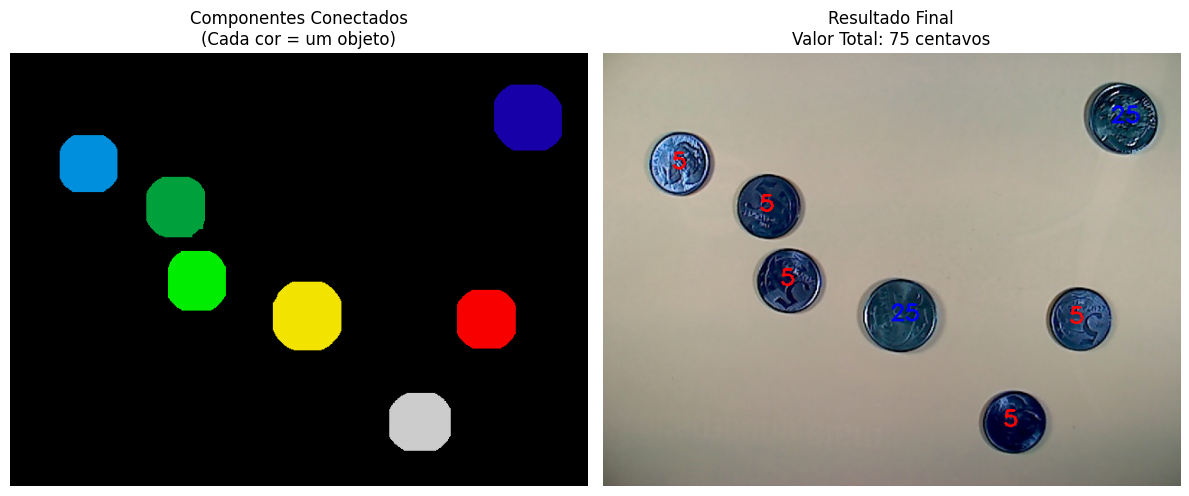


 RESUMO DA ANÁLISE:
   • Número de moedas detectadas: 7
   • Áreas dos objetos: [np.int64(4805), np.int64(3638), np.int64(3867), np.int64(3786), np.int64(5016), np.int64(3767), np.int64(3861)]
   • Valor total calculado: 75 centavos
   • Valor total em reais: R$ 0.75

PROCESSANDO IMAGEM 2: 80.jpg
Imagem carregada: (480, 640, 3)
Conversão para escala de cinza concluída

--- ETAPA DE SEGMENTAÇÃO ---
Aplicando segmentação com kernels: closing=15x15, opening=31x31


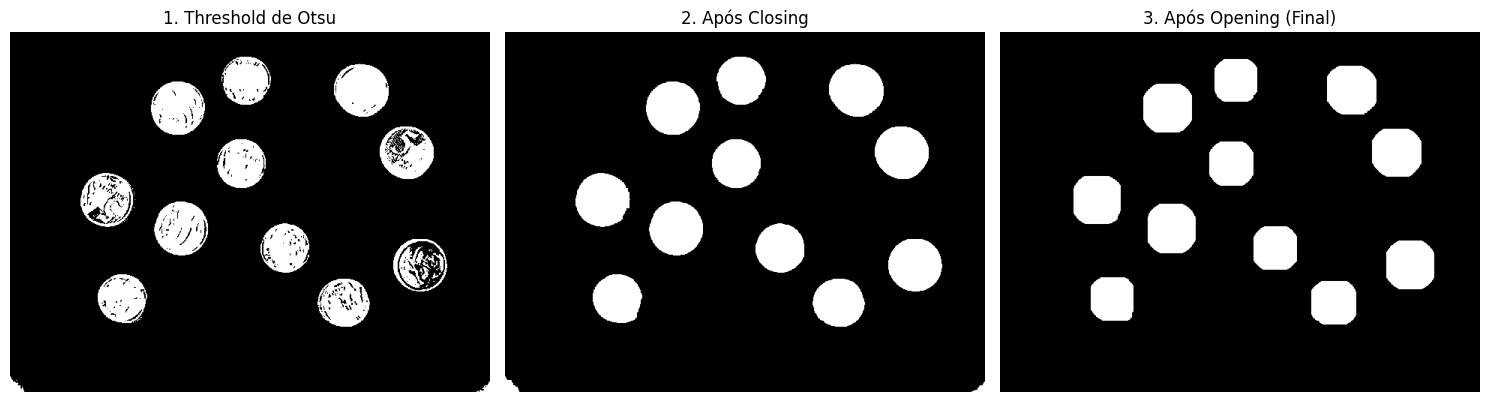


--- ANÁLISE DE COMPONENTES CONECTADOS ---
 Encontrados 11 objetos (excluindo background)

--- CÁLCULO DE ÁREAS ---
Objeto 1: 2978 pixels
Objeto 2: 3793 pixels
Objeto 3: 3775 pixels
Objeto 4: 3736 pixels
Objeto 5: 3132 pixels
Objeto 6: 3678 pixels
Objeto 7: 3778 pixels
Objeto 8: 3064 pixels
Objeto 9: 3728 pixels
Objeto 10: 3049 pixels
Objeto 11: 3183 pixels

--- CLASSIFICAÇÃO E VALORAÇÃO ---
Objeto 1: 2978 pixels → 10 centavos
Objeto 2: 3793 pixels → 5 centavos
Objeto 3: 3775 pixels → 5 centavos
Objeto 4: 3736 pixels → 5 centavos
Objeto 5: 3132 pixels → 10 centavos
Objeto 6: 3678 pixels → 5 centavos
Objeto 7: 3778 pixels → 5 centavos
Objeto 8: 3064 pixels → 10 centavos
Objeto 9: 3728 pixels → 5 centavos
Objeto 10: 3049 pixels → 10 centavos
Objeto 11: 3183 pixels → 10 centavos


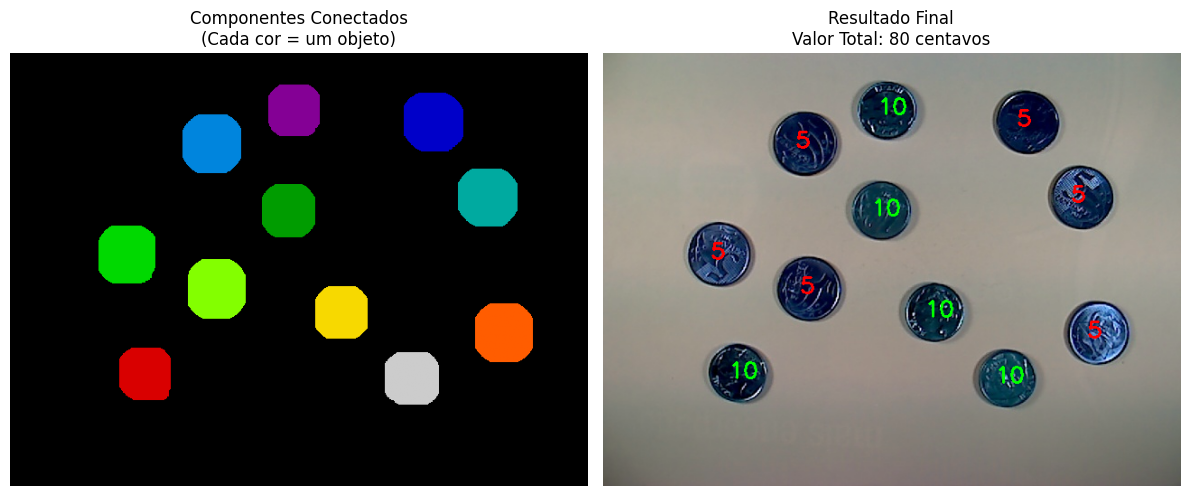


 RESUMO DA ANÁLISE:
   • Número de moedas detectadas: 11
   • Áreas dos objetos: [np.int64(2978), np.int64(3793), np.int64(3775), np.int64(3736), np.int64(3132), np.int64(3678), np.int64(3778), np.int64(3064), np.int64(3728), np.int64(3049), np.int64(3183)]
   • Valor total calculado: 80 centavos
   • Valor total em reais: R$ 0.80

PROCESSANDO IMAGEM 3: 95.jpg
Imagem carregada: (480, 640, 3)
Conversão para escala de cinza concluída

--- ETAPA DE SEGMENTAÇÃO ---
Aplicando segmentação com kernels: closing=15x15, opening=31x31


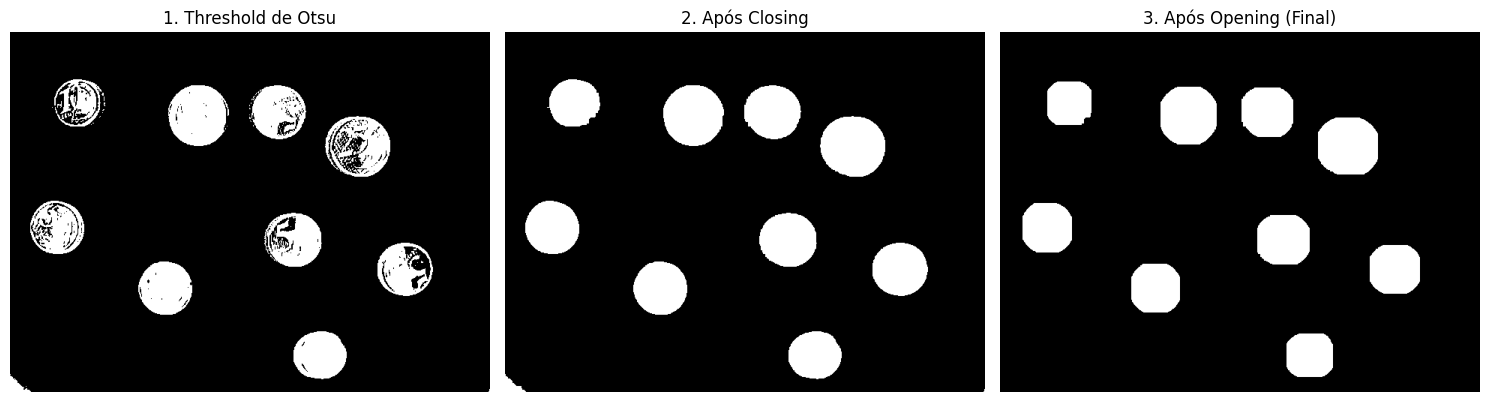


--- ANÁLISE DE COMPONENTES CONECTADOS ---
 Encontrados 9 objetos (excluindo background)

--- CÁLCULO DE ÁREAS ---
Objeto 1: 3114 pixels
Objeto 2: 4997 pixels
Objeto 3: 4017 pixels
Objeto 4: 5335 pixels
Objeto 5: 3845 pixels
Objeto 6: 4113 pixels
Objeto 7: 3897 pixels
Objeto 8: 3766 pixels
Objeto 9: 3285 pixels

--- CLASSIFICAÇÃO E VALORAÇÃO ---
Objeto 1: 3114 pixels → 10 centavos
Objeto 2: 4997 pixels → 25 centavos
Objeto 3: 4017 pixels → 5 centavos
Objeto 4: 5335 pixels → 25 centavos
Objeto 5: 3845 pixels → 5 centavos
Objeto 6: 4113 pixels → 5 centavos
Objeto 7: 3897 pixels → 5 centavos
Objeto 8: 3766 pixels → 5 centavos
Objeto 9: 3285 pixels → 10 centavos


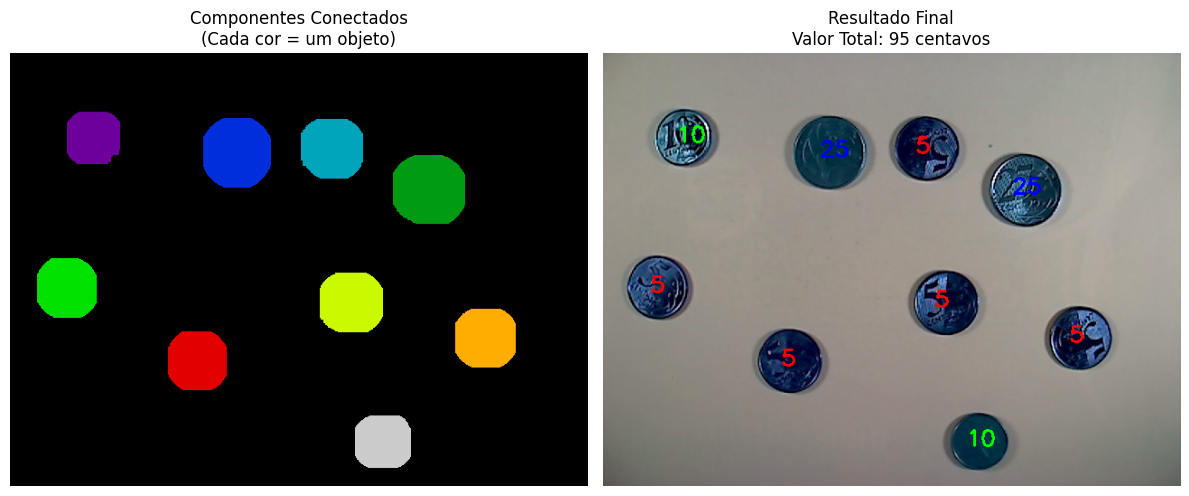


 RESUMO DA ANÁLISE:
   • Número de moedas detectadas: 9
   • Áreas dos objetos: [np.int64(3114), np.int64(4997), np.int64(4017), np.int64(5335), np.int64(3845), np.int64(4113), np.int64(3897), np.int64(3766), np.int64(3285)]
   • Valor total calculado: 95 centavos
   • Valor total em reais: R$ 0.95


In [7]:
# Processamento de cada imagem
for i, filename in enumerate(filenames):
    print(f"\n{'='*50}")
    print(f"PROCESSANDO IMAGEM {i+1}: {filename}")
    print(f"{'='*50}")
    
    # 1. Carregamento da imagem
    img = mpimg.imread(filename).astype('uint8')
    print(f"Imagem carregada: {img.shape}")
    
    # 2. Conversão para escala de cinza usando pesos padrão
    # Fórmula: 0.3*R + 0.59*G + 0.11*B (padrão ITU-R 601-2)
    img_gray = np.uint8(0.3*img[:,:,0] + 0.59*img[:,:,1] + 0.11*img[:,:,2])
    print(f"Conversão para escala de cinza concluída")
    
    # 3. Segmentação e pós-processamento
    print("\n--- ETAPA DE SEGMENTAÇÃO ---")
    seg_img = seg_and_postprocessing(img_gray, k_cl=15, k_op=31)
    
    # 4. Análise de componentes conectados
    print("\n--- ANÁLISE DE COMPONENTES CONECTADOS ---")
    # cv2.connectedComponentsWithStats retorna:
    # [0] número de labels, [1] imagem com labels, [2] stats, [3] centroides
    output = cv2.connectedComponentsWithStats(seg_img, connectivity=4)
    n_labels = output[0]
    labeled_img = output[1]
    stats = output[2]
    centroids = output[3]
    
    print(f" Encontrados {n_labels-1} objetos (excluindo background)")
    
    # Visualização da segmentação
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(labeled_img, cmap='nipy_spectral')
    plt.title('Componentes Conectados\n(Cada cor = um objeto)')
    plt.axis('off')
    
    # 5. Cálculo das áreas
    print("\n--- CÁLCULO DE ÁREAS ---")
    list_npixels = calc_npixels_label(labeled_img, n_labels)
    
    # 6. Classificação e valoração das moedas
    print("\n--- CLASSIFICAÇÃO E VALORAÇÃO ---")
    img_result = img.copy()  # Cópia para anotações
    soma_total = 0
    
    # Critérios de classificação baseados na área
    for obj_idx, area in enumerate(list_npixels):
        # Coordenadas do centride do objeto
        x = int(centroids[obj_idx+1][0])
        y = int(centroids[obj_idx+1][1])
        
        # Classificação baseada em thresholds de área
        if area < 3500:
            valor = 10  # Moeda pequena = 10 centavos
            cor_texto = (0, 255, 0)  # Verde
        elif area > 4600:
            valor = 25  # Moeda grande = 25 centavos
            cor_texto = (255, 0, 0)  # Vermelho
        else:
            valor = 5   # Moeda média = 5 centavos
            cor_texto = (0, 0, 255)  # Azul
        
        soma_total += valor
        
        # Anotação na imagem
        cv2.putText(img_result, str(valor), (x-10, y+5), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.8, cor_texto, 2)
        
        print(f"Objeto {obj_idx+1}: {area} pixels → {valor} centavos")
    
    # Exibição do resultado final
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
    plt.title(f'Resultado Final\nValor Total: {soma_total} centavos')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Resumo dos resultados
    print(f"\n RESUMO DA ANÁLISE:")
    print(f"   • Número de moedas detectadas: {len(list_npixels)}")
    print(f"   • Áreas dos objetos: {list_npixels}")
    print(f"   • Valor total calculado: {soma_total} centavos")
    print(f"   • Valor total em reais: R$ {soma_total/100:.2f}")